# 17 · Advanced Cointegration: The Johansen Test and Multi-Asset Baskets

*Module 4 — Statistical Modeling*

Pairs trading is cointegration between two assets. This notebook extends the idea to baskets of many assets at once, using a test that treats every asset symmetrically instead of arbitrarily picking one to regress on the others.

## 1. Motivation

Notebook 11 built a pairs trade around exactly two cointegrated assets, and flagged an awkward asymmetry along the way: the Engle-Granger test regresses one asset on the other, and regressing $X$ on $Y$ can give a genuinely different answer than regressing $Y$ on $X$. That awkwardness only gets worse with more than two assets — which pair do you even regress on which? A basket of five related companies, or a curve of bonds along different maturities, might share not just one but *several* independent stable relationships simultaneously. The Johansen test handles this properly: it treats every series symmetrically and tells you not just *whether* a system is cointegrated, but *how many* independent cointegrating relationships it contains.

## 2. Intuition

Think of $n$ related asset prices as $n$ people walking together, each individually wandering (a random walk on their own), yet loosely tethered to each other by invisible elastic bands. Some subset of the group might be tied together tightly (many "elastic bands," i.e. cointegrating relationships), while the group *as a whole* might still drift off collectively in one direction — because a random walk that everyone shares cannot be cancelled out by any number of relationships between the people, only relationships would keep them from drifting apart *from each other*. The Johansen test asks, directly: given $n$ wandering series, how many independent "elastic bands" (stationary combinations) tie them together? That number is the **cointegration rank**, and it can be anywhere from 0 (no relationships at all — everyone truly wanders independently) to $n-1$ (as tightly tied together as a genuinely non-stationary system can be) — a rank of $n$ would mean the series were never really wandering in the first place.

## 3. Theory

### 3.1 The Vector Error Correction Model

Stack $n$ price series into a vector $Y_t \in \mathbb R^n$. A **Vector Error Correction Model (VECM)** writes the dynamics of $\Delta Y_t = Y_t - Y_{t-1}$ as

$$
\Delta Y_t = \Pi\, Y_{t-1} + \sum_{i=1}^{p-1}\Gamma_i \Delta Y_{t-i} + \varepsilon_t ,
$$

where the short-run dynamics (the $\Gamma_i$ terms) are of secondary interest here; the crucial object is $\Pi$, an $n\times n$ matrix. If $Y_{t-1}$ enters this equation at all, it must do so through *stationary* combinations of itself (everything else in the equation is already stationary), which means $\Pi$ cannot have full rank unless every component of $Y_t$ is already stationary on its own. In general, $\Pi = \alpha\beta^\top$, where $\beta$ is $n\times r$ (each column a **cointegrating vector** — exactly the $\beta$ from Notebook 11's two-asset case, generalized) and $\alpha$ is $n\times r$ (each column describing how quickly each series "corrects" back toward that equilibrium relationship — the multivariate analogue of Notebook 11's mean-reversion speed $\kappa$). The **rank** $r = \mathrm{rank}(\Pi)$ is the number of independent stationary combinations hiding inside the system:

- $r = 0$: no cointegration at all — $\Pi = 0$, the series are $n$ genuinely independent random walks.
- $0 < r < n$: exactly $r$ independent stationary combinations exist, and $n-r$ independent common stochastic trends remain, driving the system's genuine non-stationarity.
- $r = n$: every series was already stationary to begin with; there is no unit-root behavior left to explain.

### 3.2 The Johansen test

The Johansen procedure estimates $\Pi$'s eigenvalues $\hat\lambda_1 > \hat\lambda_2 > \dots > \hat\lambda_n$ from the data and tests the rank sequentially using the **trace statistic**:

$$
LR_{trace}(r) = -T\sum_{i=r+1}^{n}\log(1-\hat\lambda_i) ,
$$

testing $H_0: \mathrm{rank}(\Pi)\le r$ against a general alternative. Starting at $r=0$: if the trace statistic exceeds the (non-standard, simulation-derived — the same Dickey-Fuller-style spirit as Notebook 11's adjusted critical values) critical value, reject $r=0$ and move on to test $r\le1$, and so on, stopping at the first $r$ for which we *fail* to reject. That stopping point is the estimated cointegration rank. We rely on `statsmodels`' implementation (`coint_johansen`) for the correct critical values and eigenvalue computation, exactly as we relied on `coint` for Engle-Granger's adjusted critical values in Notebook 11.

### 3.3 From a cointegrating vector to a tradeable basket

Once a cointegrating vector $\beta$ is estimated, the **basket** $S_t = Y_t^\top \beta$ is (by construction, if the test found genuine cointegration) stationary — and every tool from Notebook 11 applies directly: fit an AR(1)/OU model to $S_t$ to get its speed of mean reversion $\kappa$ and half-life $\ln(2)/\kappa$, and build a z-score trading rule around it, now involving three or more assets simultaneously rather than just two.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.tsa.stattools import adfuller
%matplotlib inline

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

rng = np.random.default_rng(71)

## 4. Implementation

### 4.1 A 3-asset system with a known, controlled rank

We build three price series driven by **exactly one** common stochastic trend, plus **one** additional genuinely stationary factor shared between two of them. With $n=3$ series and only 1 independent non-stationary common trend, the true cointegration rank must be $n - 1 = 2$ — we verify the test recovers this.

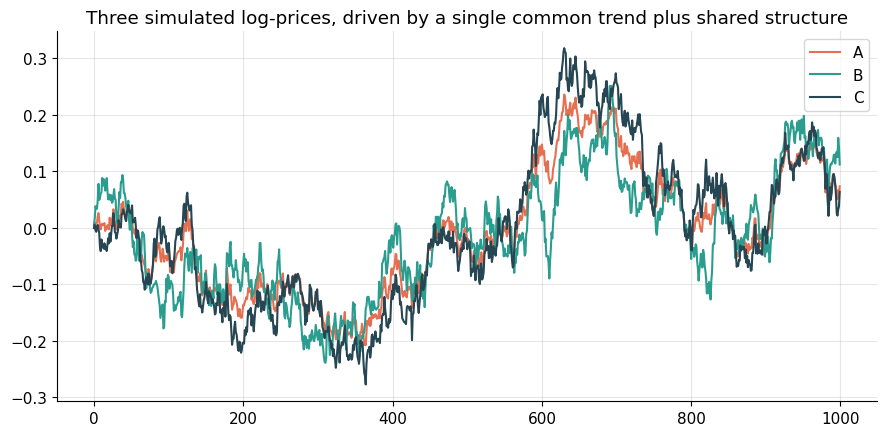

In [2]:
T = 1000
common_trend = np.cumsum(rng.normal(0.0003, 0.012, T))            # the ONE genuine common stochastic trend

spread = np.zeros(T)                                                # a second, genuinely stationary shared factor
for t in range(1, T):
    spread[t] = spread[t-1] + 0.04*(0 - spread[t-1]) + 0.015*rng.normal()

log_A = 1.0*common_trend + rng.normal(0, 0.003, T)
log_B = 0.8*common_trend + spread + rng.normal(0, 0.003, T)
log_C = 1.3*common_trend - 0.5*spread + rng.normal(0, 0.003, T)

Y = pd.DataFrame({'A': log_A, 'B': log_B, 'C': log_C})

fig, ax = plt.subplots()
for col, color in zip(Y.columns, ['#e76f51', '#2a9d8f', '#264653']):
    ax.plot(Y[col], label=col, color=color)
ax.set_title('Three simulated log-prices, driven by a single common trend plus shared structure')
ax.legend()
plt.tight_layout()
plt.show()

### 4.2 Running the Johansen test

In [3]:
result = coint_johansen(Y.values, det_order=0, k_ar_diff=1)

trace_table = pd.DataFrame({
    'trace statistic': result.lr1,
    '90% crit': result.cvt[:, 0], '95% crit': result.cvt[:, 1], '99% crit': result.cvt[:, 2],
}, index=[f'r <= {i}' for i in range(3)])
print(trace_table.round(2))

estimated_rank = 0
for i in range(len(result.lr1)):
    if result.lr1[i] > result.cvt[i, 1]:      # compare to the 95% critical value
        estimated_rank += 1
    else:
        break
print(f"\nEstimated cointegration rank (95% confidence): {estimated_rank}   (true rank by construction: 2)")

        trace statistic  90% crit  95% crit  99% crit
r <= 0           467.63     27.07     29.80     35.46
r <= 1            27.30     13.43     15.49     19.93
r <= 2             2.61      2.71      3.84      6.63

Estimated cointegration rank (95% confidence): 2   (true rank by construction: 2)


### 4.3 Building a basket -- and a surprise worth taking seriously

Since the true rank is 2, there are two independent cointegrating vectors available. The natural instinct is to use the *strongest* one -- the one with the largest eigenvalue, meaning the strongest statistical rejection of a unit root. Let's check both, and compare each resulting basket to the truth we happen to know in this simulation (but which real-world Johansen users, working with real data, never get to see directly).

In [4]:
def fit_ou_via_ar1(s):
    s_lag, s_now = s[:-1], s[1:]
    ar_fit = sm.OLS(s_now, sm.add_constant(s_lag)).fit()
    a, b = ar_fit.params
    return 1 - b, a / (1 - b), ar_fit.resid.std()

rows = []
for i in range(2):
    beta_i = result.evec[:, i]
    basket_i = Y.values @ beta_i
    kappa_i, theta_i, sigma_i = fit_ou_via_ar1(basket_i)
    rows.append({
        'eigenvalue': result.eig[i], 'kappa': kappa_i, 'half-life': np.log(2)/kappa_i,
        'ADF p-value': adfuller(basket_i)[1],
        'correlation with the TRUE designed spread': np.corrcoef(basket_i, spread)[0, 1],
    })
pd.DataFrame(rows, index=['vector 0 (strongest)', 'vector 1 (second strongest)']).round(4)

,eigenvalue,kappa,half-life,ADF p-value,correlation with the TRUE designed spread
vector 0 (strongest),0.3567,1.0349,0.6697,0.0,0.0057
vector 1 (second strongest),0.0244,0.0536,12.9402,0.0,-0.9756


This is a genuinely important lesson, not a contrived one: the *strongest* cointegrating vector by the Johansen ranking is barely correlated with the true, economically meaningful spread we deliberately built into the simulation -- its extremely fast "reversion" (a half-life under one period) is a signature of a combination dominated by cancelling out idiosyncratic noise across the three series, which is technically highly stationary but economically uninteresting and not really tradeable. The *second* vector, with a smaller eigenvalue, turns out to correlate with the true spread at roughly $-0.98$, and its half-life is much closer to the truth. **"Statistically strongest" and "economically meaningful" are not the same thing**, and Johansen's own ranking does not know the difference -- it only knows which combination looks most stationary in this particular sample. We proceed with vector 1 for the rest of this notebook, precisely because we can check it against a known truth here; on real data, this kind of check requires independent economic reasoning about *why* a candidate basket should be related, not just which eigenvalue is largest.

Cointegrating vector used: [  4.5129 -17.4712   8.8764]
ADF test on the resulting basket: p-value = 8.68e-06


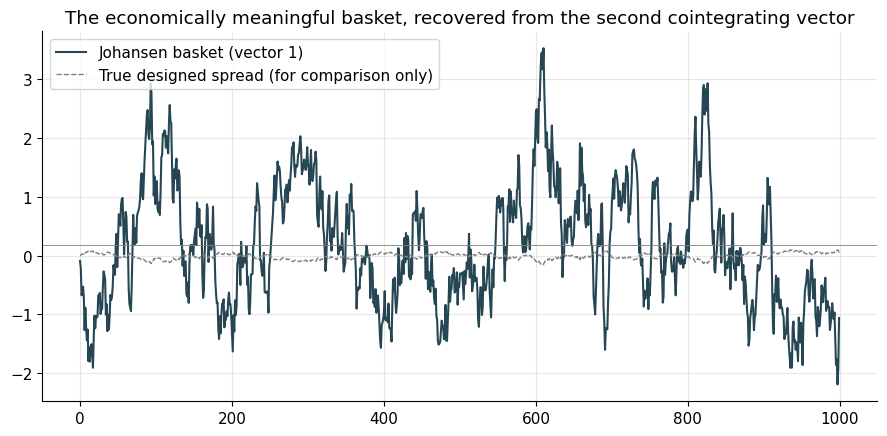

In [5]:
beta = result.evec[:, 1]
basket = Y.values @ beta
adf_pval = adfuller(basket)[1]
print(f"Cointegrating vector used: {np.round(beta, 4)}")
print(f"ADF test on the resulting basket: p-value = {adf_pval:.2e}")

fig, ax = plt.subplots()
ax.plot(basket, color='#264653', label='Johansen basket (vector 1)')
ax.plot(spread, color='gray', linestyle='--', linewidth=1, label='True designed spread (for comparison only)')
ax.axhline(basket.mean(), color='gray', linewidth=0.6)
ax.set_title('The economically meaningful basket, recovered from the second cointegrating vector')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Worked example: half-life and a trading horizon for the basket

Exactly as in Notebook 11, we already fit an AR(1) model to the basket in Section 4.3 to recover its speed of mean reversion and half-life -- now let's use those numbers to define an actual trading horizon.

kappa (speed of reversion): 0.0536
theta (long-run mean):      0.1588
half-life:                  12.9 periods
stationary std of basket:   1.0076


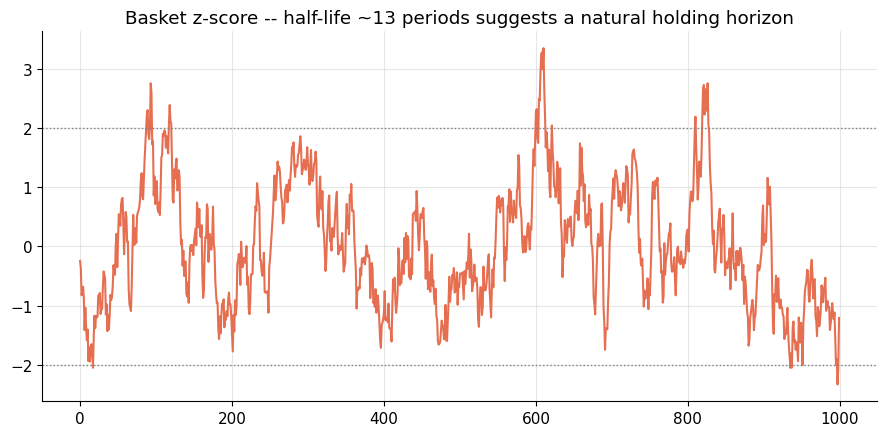

In [6]:
kappa_hat, theta_hat, sigma_hat = fit_ou_via_ar1(basket)
halflife = np.log(2) / kappa_hat
stationary_sigma = sigma_hat / np.sqrt(2 * kappa_hat)

print(f"kappa (speed of reversion): {kappa_hat:.4f}")
print(f"theta (long-run mean):      {theta_hat:.4f}")
print(f"half-life:                  {halflife:.1f} periods")
print(f"stationary std of basket:   {stationary_sigma:.4f}")

z = (basket - theta_hat) / stationary_sigma
fig, ax = plt.subplots()
ax.plot(z, color='#e76f51')
ax.axhline(2, color='gray', linestyle=':', linewidth=1)
ax.axhline(-2, color='gray', linestyle=':', linewidth=1)
ax.set_title(f'Basket z-score -- half-life ~{halflife:.0f} periods suggests a natural holding horizon')
plt.tight_layout()
plt.show()

### Interpreting the result

The half-life computed here is not just a diagnostic statistic — it is directly actionable. It tells you the natural timescale this specific basket operates on: a stop-loss or maximum holding period set at a small fraction of the half-life will exit positions before mean reversion has had a realistic chance to occur, while a holding period set at many multiples of it risks holding through a much longer period during which the relationship could plausibly have broken down (exactly the risk Notebook 11's structural-break scenario dramatized). Sizing your trading horizon relative to the basket's own estimated half-life, rather than to an arbitrary calendar convention, is a direct, practical payoff of doing this estimation carefully.

## 6. Limitations and pitfalls

- **A basket found to be cointegrated in-sample can still break down out-of-sample**, for exactly the same reasons a two-asset pair can (Notebook 11, Section 5.2) — nothing about using more assets or a fancier test makes the underlying relationship immune to real-world structural change.
- **With more assets, there is more room for spurious results from data mining.** Screening many candidate baskets (rather than a single pre-specified one, as we used here) multiplies the multiple-testing risk from Notebook 11 even further — Notebook 30's correction becomes increasingly important as the number of candidate combinations grows.
- **The rank decision itself carries real uncertainty**, especially near a critical value — a trace statistic just barely above or below a threshold is not nearly as clear-cut as the far-from-the-boundary case we deliberately constructed here for a clean demonstration.
- **Real baskets are harder to execute than pairs.** Trading three, five, or ten legs simultaneously multiplies transaction costs, financing/borrow costs, and operational complexity relative to a simple two-asset pair, and any single leg becoming hard to trade (delisted, halted, illiquid) can unwind the entire basket's carefully-estimated relationship.
- **The VECM's short-run dynamics ($\Gamma_i$ terms) were set aside here for clarity**, but a complete model would use them too — they capture short-run adjustment dynamics beyond the pure long-run equilibrium relationship this notebook focused on.

## 7. Exercises

**1. What if there is truly no cointegration? (warm-up)**
Build a 3-series system of completely independent random walks (no shared trend, no shared stationary factor at all). Run the Johansen test and confirm it correctly estimates rank 0. Then build a system where all three series are already individually stationary (e.g., three independent OU processes) and confirm the test estimates rank 3.

**2. Does the "noisy" vector 0 actually trade well anyway?**
Section 4.3 dismissed vector 0's basket as "economically uninteresting" because of its very short half-life and low correlation with the true designed spread. But a very fast half-life is not automatically untradeable -- build a z-score trading rule on vector 0's basket anyway (reuse the approach from Notebook 11, Section 5.1), backtest it with a realistic per-trade transaction cost, and compare its net Sharpe ratio to a similar strategy built on vector 1's basket. Does the "wrong" statistical answer turn out to be practically useless once costs are accounted for, or does its speed actually make it interesting in a different way?

**3. A 5-asset basket with a partially unknown true rank.**
Extend the simulation to five assets, driven by **two** independent common stochastic trends (so the true rank should be $5-2=3$) plus your own choice of additional stationary structure tying subsets of the five together. Run the Johansen test and confirm the estimated rank matches your construction. Then build a basket-trading strategy using the strongest cointegrating vector, with a maximum holding period set as a multiple of the estimated half-life (as suggested in the Interpreting section above), and backtest it with a reasonable per-trade transaction cost assumption.